<a href="https://colab.research.google.com/github/lordsiiya/Timer101/blob/master/Copy_of_GROUP_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  **MACHINE LEARNING ASSIGNMENT**

      TITLE: Mobile Money Fraud Detection Using      
       Classical Machine Learning Techniques

             **GROUP NUMBER:GROUP  3**

          LECTURER: DR. DENISH AZAMUKE


Member-Name_________________Student-Number

1. Ayebare Edgar.................MAY26/MAIDS/0240U
2. Tankiso Molahli..................MAY26/AI&DS/0351X
3. Derrick Namisi



## Import Libraries

In [2]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Data Description

In [3]:
# Load Dataset

path = "/content/drive/MyDrive/Copy of synthetic_mobile_money_transaction_dataset.csv"
df = pd.read_csv(path)

In [4]:
# Display first 5 and last 5 rows of the data files for inspection
df.head()

,step,transactionType,amount,initiator,oldBalInitiator,newBalInitiator,recipient,oldBalRecipient,newBalRecipient,isFraud
0,0,TRANSFER,19824.96,4537027967639631,187712.18,167887.22,4875702729424478,8.31,19833.27,1
1,0,PAYMENT,598.97,4296267625767470,8.92,8.92,25-0000401,0.00,0.00,0
2,0,PAYMENT,545.85,4178224023847746,93.60,-452.25,13-0001587,0.00,545.85,0
3,0,TRANSFER,19847.01,4178224023847746,-452.25,-20299.26,4096920916696293,4011.72,23858.74,1
4,0,PAYMENT,546.89,4779013371563747,159148.76,158601.88,75-0003564,0.00,546.89,0


In [5]:
# Make a copy
clean_df = df.copy()

In [6]:
# Count duplicates rows
clean_df.duplicated().sum()

np.int64(0)

In [7]:
# Check for number of rows with null values
clean_df.isnull().sum()

,0
step,0
transactionType,0
amount,0
initiator,0
oldBalInitiator,0
newBalInitiator,0
recipient,0
oldBalRecipient,0
newBalRecipient,0
isFraud,0


In [8]:
# Describe dataset
clean_df.describe()

,step,amount,initiator,oldBalInitiator,newBalInitiator,oldBalRecipient,newBalRecipient,isFraud
count,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06,1.720181e+06
mean,6.555529e+01,5.253868e+04,4.499952e+15,2.433758e+06,2.443880e+06,1.085083e+05,1.222772e+05,1.020346e-01
std,4.467368e+01,8.835650e+04,2.896351e+14,1.307615e+06,1.297181e+06,2.830138e+05,3.192277e+05,3.026939e-01
min,0.000000e+00,2.400000e-01,4.000062e+15,-1.999971e+05,-1.999971e+05,-1.983685e+05,-1.357280e+05,0.000000e+00
25%,2.300000e+01,6.064600e+02,4.248762e+15,1.577186e+06,1.600496e+06,1.606423e+04,2.496233e+04,0.000000e+00
50%,5.400000e+01,1.729825e+04,4.508521e+15,2.619827e+06,2.625680e+06,6.313018e+04,7.448161e+04,0.000000e+00
75%,1.060000e+02,7.116149e+04,4.750928e+15,3.361338e+06,3.361872e+06,1.373822e+05,1.431702e+05,0.000000e+00
max,1.430000e+02,2.142928e+06,4.999855e+15,1.224469e+07,1.224469e+07,1.188554e+07,1.206621e+07,1.000000e+00


In [9]:
# Summarize the dataset structure by showing column names, data types, number of non-missing values and overall size
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720181 entries, 0 to 1720180
Data columns (total 10 columns):
 #   Column           Dtype  
---  ------           -----  
 0   step             int64  
 1   transactionType  object 
 2   amount           float64
 3   initiator        int64  
 4   oldBalInitiator  float64
 5   newBalInitiator  float64
 6   recipient        object 
 7   oldBalRecipient  float64
 8   newBalRecipient  float64
 9   isFraud          int64  
dtypes: float64(5), int64(3), object(2)
memory usage: 131.2+ MB


## Exploratory Data Analysis

In [10]:
# Distribution of target variable (isFraud)
clean_df['isFraud'].value_counts()

,count
isFraud,
0,1544663
1,175518


In [11]:
clean_df.shape


(1720181, 10)

In [12]:
# Calculate fraud percentage
round((clean_df['isFraud'].value_counts()[1] / clean_df.shape[0]) * 100,2)

np.float64(10.2)

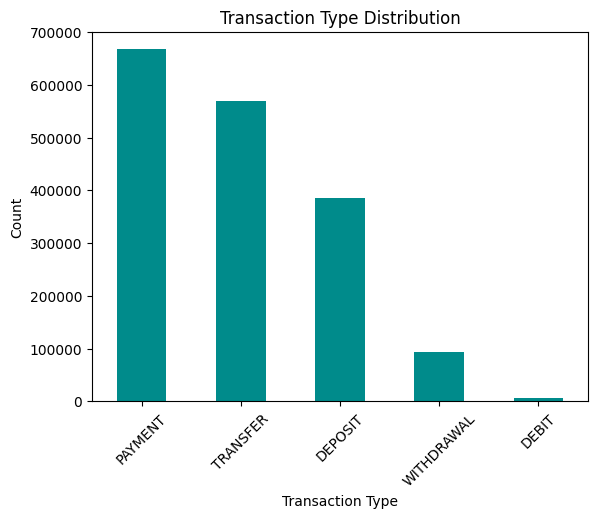

In [13]:
# Visualization by transaction type
clean_df['transactionType'].value_counts().plot(kind='bar', color = 'darkcyan')
plt.title('Transaction Type Distribution')
plt.xlabel('Transaction Type')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

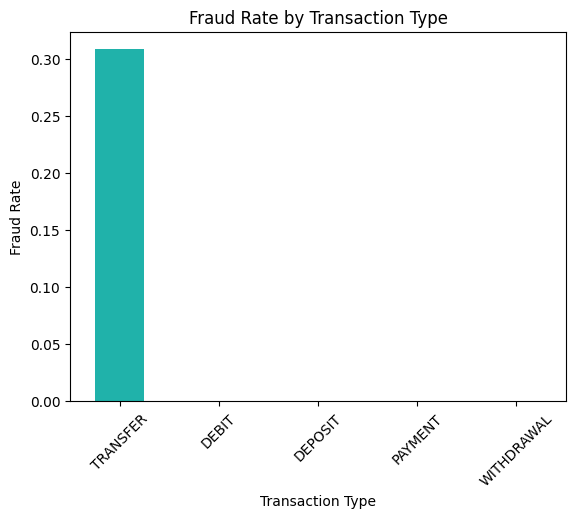

transactionType
TRANSFER      0.30829
DEBIT         0.00000
DEPOSIT       0.00000
PAYMENT       0.00000
WITHDRAWAL    0.00000
Name: isFraud, dtype: float64


In [14]:
# Fraud rate by type
fraud_rate_by_type = clean_df.groupby('transactionType')['isFraud'].mean().sort_values(ascending=False)
fraud_rate_by_type.plot(kind='bar', color = 'lightseagreen')
plt.title('Fraud Rate by Transaction Type')
plt.xlabel('Transaction Type')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.show()
print(fraud_rate_by_type)

In [15]:
# Check amount statisctics
clean_df['amount'].describe().astype(int)

,amount
count,1720181
mean,52538
std,88356
min,0
25%,606
50%,17298
75%,71161
max,2142928


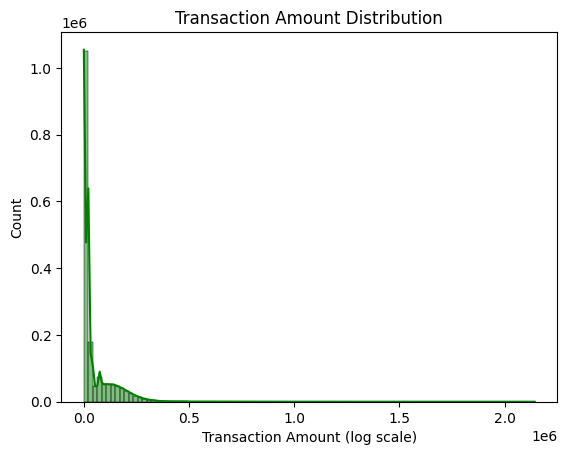

In [16]:
# Visualize transaction amount distribution
sns.histplot(clean_df['amount'], bins=100, kde = True, color = 'green')
plt.title('Transaction Amount Distribution')
plt.xlabel('Transaction Amount (log scale)')
plt.ylabel('Count')
plt.show()

Text(0.5, 1.0, 'Fraud distribution Chart')

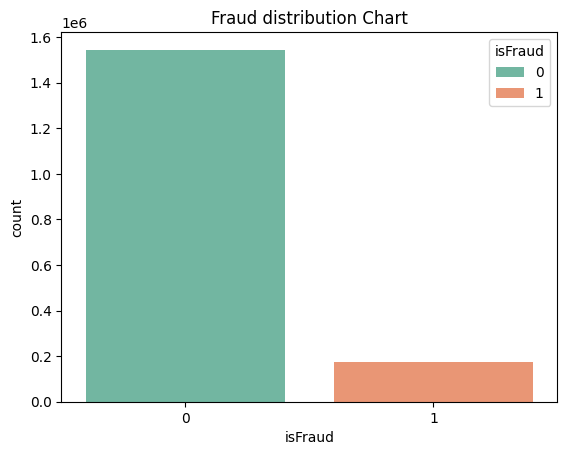

In [17]:
# isFraud distribution visualization
sns.countplot(x='isFraud', data=clean_df, palette='Set2', hue='isFraud', color='skyblue')
plt.title('Fraud distribution Chart')

In [18]:
# Summary stats for fraudulent and normal transactions
clean_df.groupby('isFraud')['amount'].describe()

,count,mean,std,min,25%,50%,75%,max
isFraud,,,,,,,,
0,1544663.0,55612.542285,92545.222273,0.24,599.78,17062.90,78638.275,2142928.28
1,175518.0,25486.856223,17980.355818,16804.02,17084.69,19631.62,24615.560,632938.42


([0, 1, 2, 3, 4],
 [Text(0, 0, 'TRANSFER'),
  Text(1, 0, 'PAYMENT'),
  Text(2, 0, 'DEPOSIT'),
  Text(3, 0, 'WITHDRAWAL'),
  Text(4, 0, 'DEBIT')])

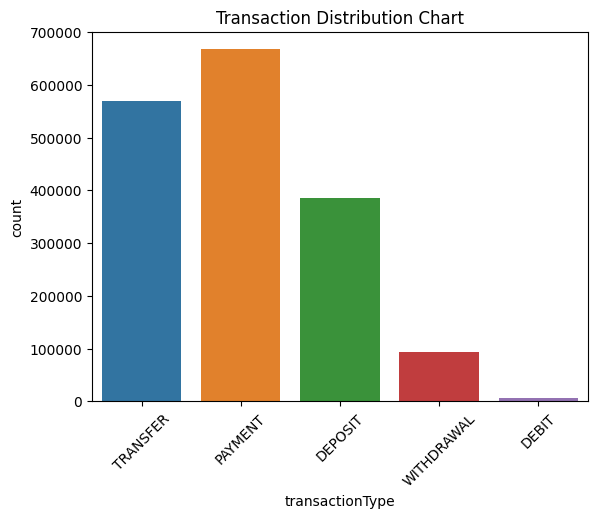

In [19]:
# Transaction type distribution visualization
sns.countplot(x='transactionType', data=clean_df, hue='transactionType')
plt.title('Transaction Distribution Chart')
plt.xticks(rotation=45)

## Data cleaning and preprocessing

In [20]:
clean_df.columns


Index(['step', 'transactionType', 'amount', 'initiator', 'oldBalInitiator',
       'newBalInitiator', 'recipient', 'oldBalRecipient', 'newBalRecipient',
       'isFraud'],
      dtype='object')

In [21]:
# Standardize data
clean_df['recipient'] = clean_df['recipient'].replace('-', '', regex=True)



In [22]:
# User with fraudulant transfers
clean_df[clean_df['isFraud'] == 1]['initiator'].value_counts()


,count
initiator,
4654047633050507,198
4971664085133015,184
4828576380583261,154
4945482194025615,149
4897326195323396,148
...,...
4484386596913418,1
4985894369373334,1
4514751810208875,1


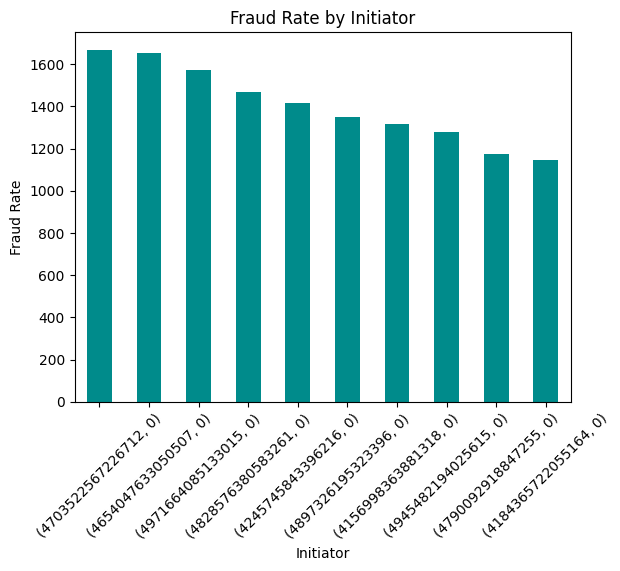

In [23]:
# Visualize fraud distribution by initiator
fraud_rate_by_initiator = clean_df.groupby('initiator')['isFraud'].value_counts().sort_values(ascending=False).head(10)
fraud_rate_by_initiator.plot(kind='bar', color = 'darkcyan')
plt.title('Fraud Rate by Initiator')
plt.xlabel('Initiator')
plt.ylabel('Fraud Rate')
plt.xticks(rotation=45)
plt.show()


Text(0.5, 1.0, 'Distribution of Amount by isFraud')

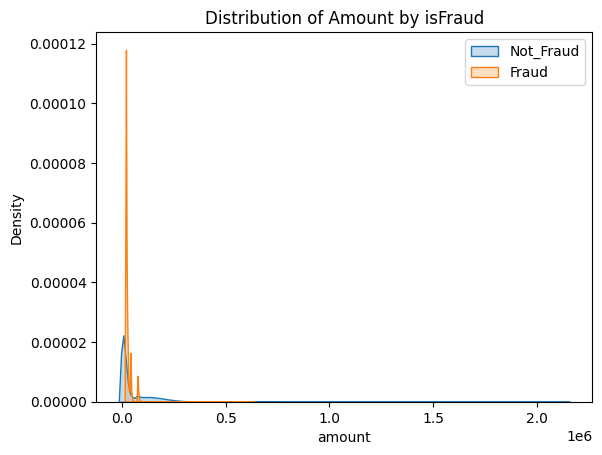

In [24]:
# Visualize feature distribution for fraud and normal transaction
sns.kdeplot(clean_df[clean_df['isFraud']==0]['amount'], label='Not_Fraud', fill=True)
sns.kdeplot(clean_df[clean_df['isFraud']==1]['amount'], label='Fraud', fill=True)
plt.legend()
plt.title('Distribution of Amount by isFraud')


## Feature Engineering

In [25]:
clean_df.columns

Index(['step', 'transactionType', 'amount', 'initiator', 'oldBalInitiator',
       'newBalInitiator', 'recipient', 'oldBalRecipient', 'newBalRecipient',
       'isFraud'],
      dtype='object')

In [26]:
# Balance difference Initiator
clean_df['Amount_Difference'] = clean_df['oldBalInitiator'] - clean_df['newBalInitiator']

In [27]:
# Balance difference Reciept
clean_df['Reciever_New Balance'] = clean_df['newBalRecipient'] - clean_df['oldBalRecipient']

In [28]:
# Sender balance discrepancy
clean_df['Sender_Balance_Discrepancy'] = clean_df['oldBalInitiator'] - clean_df['newBalInitiator']

In [29]:
# Reciever balance discrepancy
clean_df['Reciever_Balance_Discrepancy'] = clean_df['oldBalRecipient'] - clean_df['newBalRecipient']

## Model Development



In [30]:
# import libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_recall_curve,  roc_auc_score,  precision_score, recall_score, f1_score, average_precision_score
from sklearn.preprocessing import StandardScaler, LabelEncoder



In [31]:
# Encode data
label_encoder = LabelEncoder()
clean_df['transactionType'] = label_encoder.fit_transform(clean_df['transactionType'])
clean_df['recipient'] = label_encoder.fit_transform(clean_df['recipient'])
clean_df['initiator'] = label_encoder.fit_transform(clean_df['initiator'])
clean_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1720181 entries, 0 to 1720180
Data columns (total 14 columns):
 #   Column                        Dtype  
---  ------                        -----  
 0   step                          int64  
 1   transactionType               int64  
 2   amount                        float64
 3   initiator                     int64  
 4   oldBalInitiator               float64
 5   newBalInitiator               float64
 6   recipient                     int64  
 7   oldBalRecipient               float64
 8   newBalRecipient               float64
 9   isFraud                       int64  
 10  Amount_Difference             float64
 11  Reciever_New Balance          float64
 12  Sender_Balance_Discrepancy    float64
 13  Reciever_Balance_Discrepancy  float64
dtypes: float64(9), int64(5)
memory usage: 183.7 MB


In [32]:
# Drop step, initiator and recipient
clean_df = clean_df.drop('step', axis=1)
clean_df = clean_df.drop('initiator', axis=1)
clean_df = clean_df.drop('recipient', axis=1)

In [33]:
clean_df


,transactionType,amount,oldBalInitiator,newBalInitiator,oldBalRecipient,newBalRecipient,isFraud,Amount_Difference,Reciever_New Balance,Sender_Balance_Discrepancy,Reciever_Balance_Discrepancy
0,3,19824.96,187712.18,167887.22,8.31,19833.27,1,19824.96,19824.96,19824.96,-19824.96
1,2,598.97,8.92,8.92,0.00,0.00,0,0.00,0.00,0.00,0.00
2,2,545.85,93.60,-452.25,0.00,545.85,0,545.85,545.85,545.85,-545.85
3,3,19847.01,-452.25,-20299.26,4011.72,23858.74,1,19847.01,19847.02,19847.01,-19847.02
4,2,546.89,159148.76,158601.88,0.00,546.89,0,546.88,546.89,546.88,-546.89
...,...,...,...,...,...,...,...,...,...,...,...
1720176,1,189001.06,3153757.97,3342759.03,132293.79,132293.79,0,-189001.06,0.00,-189001.06,0.00
1720177,2,700.80,4949410.71,4948709.91,143754.84,144455.64,0,700.80,700.80,700.80,-700.80
1720178,3,83799.76,4948709.91,4864910.15,16908.07,100707.82,1,83799.76,83799.75,83799.76,-83799.75
1720179,2,599.78,3739281.18,3738681.40,109393.87,109993.65,0,599.78,599.78,599.78,-599.78


In [34]:
# Checking class Imbalance
target_col = 'isFraud'
clean_df[target_col].value_counts()
clean_df[target_col].value_counts(normalize=True) * 100

,proportion
isFraud,
0,89.796539
1,10.203461


In [35]:
# Train-test split
X = clean_df.drop(columns=[target_col], axis=1)
y = clean_df[target_col]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)



(1376144, 10) (344037, 10)


In [36]:
# Data scaling
# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

## Model Training and evaluation

LOGISTIC REGRESSION

In [37]:
# Baseline model training and evaluation (Logistic Regression)


baseline_lr = LogisticRegression(max_iter=1000)
baseline_lr.fit(X_train, y_train)

y_pred = baseline_lr.predict(X_test)
y_proba = baseline_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC:', average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.90      1.00      0.95    308933
           1       0.01      0.00      0.00     35104

    accuracy                           0.90    344037
   macro avg       0.45      0.50      0.47    344037
weighted avg       0.81      0.90      0.85    344037

[[308492    441]
 [ 35101      3]]
ROC-AUC: 0.7464664512555597
PR-AUC: 0.18458596809328787


In [38]:
# Apply Weights on Logistic Regression
weighted_model_lr = LogisticRegression(class_weight='balanced', max_iter=1000)
weighted_model_lr.fit(X_train, y_train)

y_pred = weighted_model_lr.predict(X_test)
y_proba = weighted_model_lr.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC:', average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.98      0.65      0.78    308933
           1       0.23      0.91      0.36     35104

    accuracy                           0.68    344037
   macro avg       0.61      0.78      0.57    344037
weighted avg       0.91      0.68      0.74    344037

[[200306 108627]
 [  3072  32032]]
ROC-AUC: 0.8207230820583298
PR-AUC: 0.2653716103110435


In [39]:
# Apply SMOTE on Logistic Regression
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)

# Train model
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)
smote_model_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
    )

smote_model_lr.fit(X_train_smote, y_train_smote)

# Predictions
y_pred = smote_model_lr.predict(X_test)
y_proba = smote_model_lr.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC:', average_precision_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       1.00      0.75      0.86    308933
           1       0.31      0.98      0.47     35104

    accuracy                           0.77    344037
   macro avg       0.65      0.87      0.66    344037
weighted avg       0.93      0.77      0.82    344037

[[231684  77249]
 [   532  34572]]
ROC-AUC: 0.8758579505108212
PR-AUC: 0.31209207196921274


RANDOM FOREST

In [ ]:
# Baseline model training and Evaluation Random forest
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)


In [ ]:
# Baseline Random Forest Evaluation
y_pred = rf_model.predict(X_test)
y_proba = rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC:', average_precision_score(y_test, y_proba))

In [ ]:
# Weighted Random Forest
weighted_rf_model = RandomForestClassifier(
    class_weight='balanced',
    random_state=42,
    )
weighted_rf_model.fit(X_train, y_train)

y_pred = weighted_rf_model.predict(X_test)
y_proba = weighted_rf_model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC:', average_precision_score(y_test, y_proba))

In [ ]:
# Apply SMOTE to Random forest
from imblearn.over_sampling import SMOTE
rf_smote = RandomForestClassifier(random_state=42)

rf_smote.fit(X_train_smote, y_train_smote)

# Predict Random Forest
y_pred = rf_smote.predict(X_test)
y_proba = rf_smote.predict_proba(X_test)[:, 1]

# Evaluation
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))


In [ ]:
# HYPERPARAMETER TUNING RANDOM FOREST
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# Pipeline
pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('rf', RandomForestClassifier(
        random_state=42,
        n_jobs=-1
        ))
    ])

param_dist = {
    'rf__n_estimators': [100, 200],
    'rf__max_depth': [10, 20],
    'rf__min_samples_split': [2, 5],
    'rf__min_samples_leaf': [1, 2],
    'rf__max_features': ['sqrt', 'log2'],
    'rf__class_weight': ['balanced', 'balanced_subsample', None]
}

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
    )

random_search = RandomizedSearchCV(
    estimator=pipeline,
    param_distributions=param_dist,
    n_iter=50,
    cv=cv,
    scoring='f1',
    n_jobs=-1,
    random_state=42
    )

# Fit random forest
random_search.fit(X_train, y_train)


print('Best Paramenters:', random_search.best_params_)
print('Best CV Score:', random_search.best_score_)

best_model = random_search.best_estimator_

# Test predictions
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]


print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))
print('PR-AUC:', average_precision_score(y_test, y_proba))